In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df=pd.read_csv('Students Social Media Addiction.csv')
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [6]:
df.shape

(705, 13)

In [7]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [8]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [9]:
## Q  What is the average daily usage of social media among students?
avg_usage = df['Avg_Daily_Usage_Hours'].mean()
print(f"Average Daily Social Media Usage: {avg_usage:.2f} hours")


Average Daily Social Media Usage: 4.92 hours


In [10]:
##What is the gender distribution in the dataset?
gender_counts = df['Gender'].value_counts()
print(gender_counts)


Gender
Female    353
Male      352
Name: count, dtype: int64


In [11]:
##How many students reported that social media affects their academic performance?
affects_academic = df['Affects_Academic_Performance'].value_counts()
print(affects_academic)


Affects_Academic_Performance
Yes    453
No     252
Name: count, dtype: int64


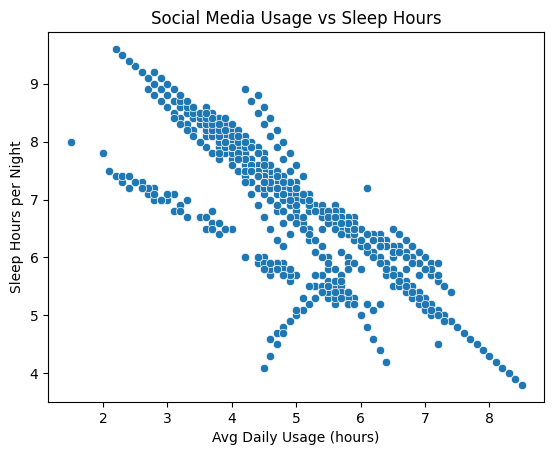

In [12]:
##What is the relationship between daily social media use and sleep hours?
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='Avg_Daily_Usage_Hours', y='Sleep_Hours_Per_Night')
plt.title("Social Media Usage vs Sleep Hours")
plt.xlabel("Avg Daily Usage (hours)")
plt.ylabel("Sleep Hours per Night")
plt.show()


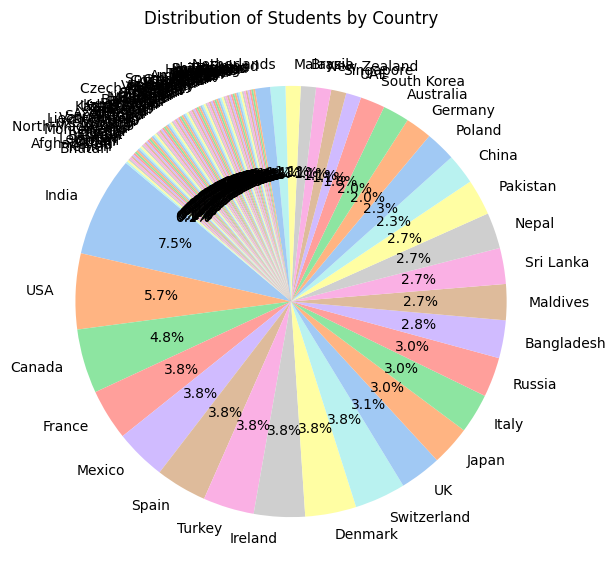

In [28]:
##What is the distribution of students by country? (Pie Chart)
country_counts = df['Country'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Distribution of Students by Country")
plt.show()

In [13]:
##Which platform is the most used among students?
most_used = df['Most_Used_Platform'].value_counts()
print(most_used)


Most_Used_Platform
Instagram    249
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      21
WeChat        15
Snapchat      13
VKontakte     12
LINE          12
KakaoTalk     12
YouTube       10
Name: count, dtype: int64


In [14]:
##What is the average mental health score by relationship status?
mental_health_by_rel = df.groupby('Relationship_Status')['Mental_Health_Score'].mean()
print(mental_health_by_rel)


Relationship_Status
Complicated        5.937500
In Relationship    6.297578
Single             6.197917
Name: Mental_Health_Score, dtype: float64


In [15]:
## Is there a significant difference in addiction scores between undergraduate and graduate students?
import scipy.stats as stats

undergrad = df[df['Academic_Level'] == 'Undergraduate']['Addicted_Score']
graduate = df[df['Academic_Level'] == 'Graduate']['Addicted_Score']
t_stat, p_val = stats.ttest_ind(undergrad, graduate)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")


T-statistic: 2.08, P-value: 0.0383


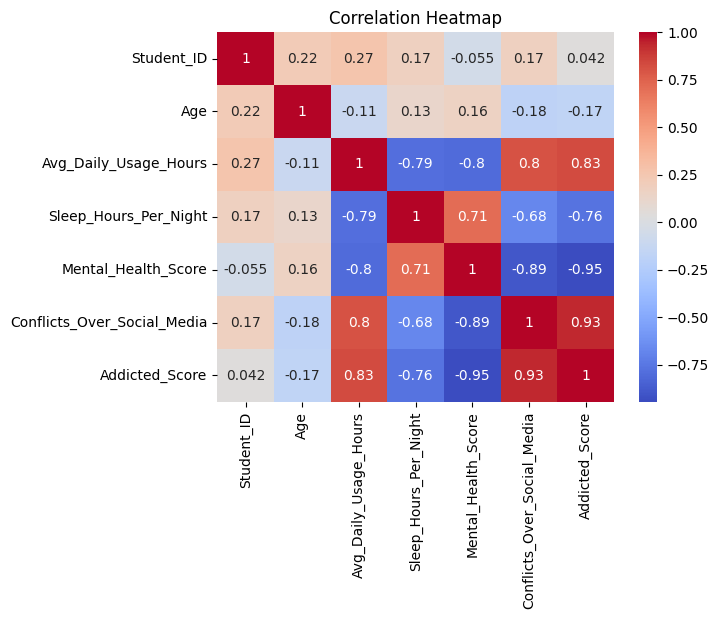

In [16]:
##Create a heatmap showing correlation among numerical variables
correlation = df.select_dtypes(include='number').corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [18]:
##. Which academic level reports the highest average social media usage?
avg_usage_by_level = df.groupby('Academic_Level')['Avg_Daily_Usage_Hours'].mean()
print(avg_usage_by_level)


Academic_Level
Graduate         4.776923
High School      5.544444
Undergraduate    5.001416
Name: Avg_Daily_Usage_Hours, dtype: float64


In [19]:
##What is the distribution of relationship status among students?
relationship_distribution = df['Relationship_Status'].value_counts()
print(relationship_distribution)

Relationship_Status
Single             384
In Relationship    289
Complicated         32
Name: count, dtype: int64


In [20]:
##Is there a trend between the most used platform and addicted score?
platform_addiction = df.groupby('Most_Used_Platform')['Addicted_Score'].mean().sort_values(ascending=False)
print(platform_addiction)

Most_Used_Platform
WhatsApp     7.462963
Snapchat     7.461538
TikTok       7.428571
Instagram    6.554217
YouTube      6.100000
WeChat       6.066667
KakaoTalk    6.000000
Facebook     5.666667
Twitter      5.500000
VKontakte    5.000000
LinkedIn     3.809524
LINE         3.000000
Name: Addicted_Score, dtype: float64


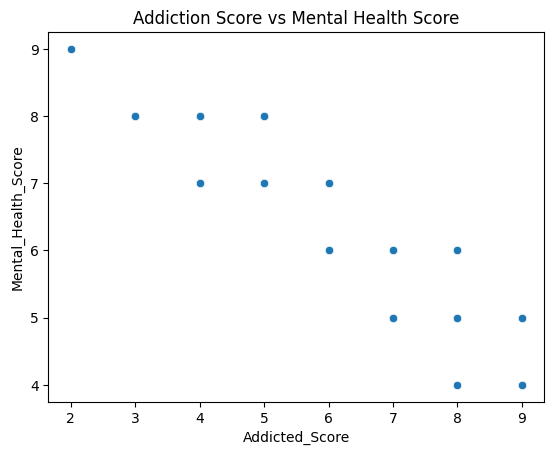

In [21]:
##Do students with higher addiction scores tend to report lower mental health scores?
sns.scatterplot(data=df, x='Addicted_Score', y='Mental_Health_Score')
plt.title("Addiction Score vs Mental Health Score")
plt.show()

In [22]:
## How many students reported 3 or more conflicts over social media?
high_conflict_count = (df['Conflicts_Over_Social_Media'] >= 3).sum()
print(f"Students with 3 or more social media conflicts: {high_conflict_count}")

Students with 3 or more social media conflicts: 450


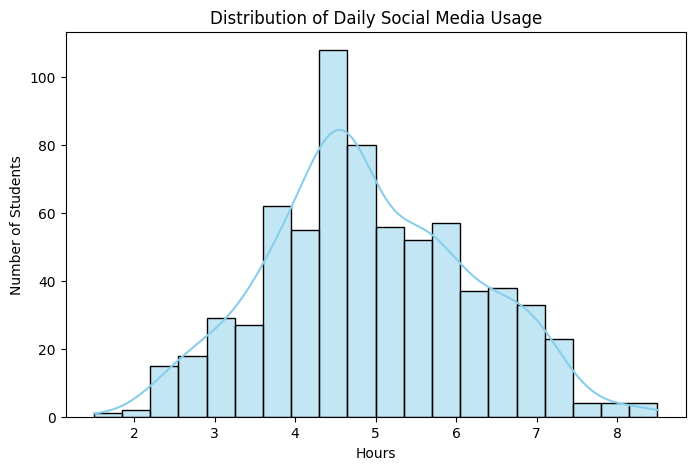

In [23]:
## What is the distribution of average daily social media usage among students? (Histogram)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['Avg_Daily_Usage_Hours'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Daily Social Media Usage")
plt.xlabel("Hours")
plt.ylabel("Number of Students")
plt.show()


<ipython-input-24-c49a0864231e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Academic_Level', palette='Set2')


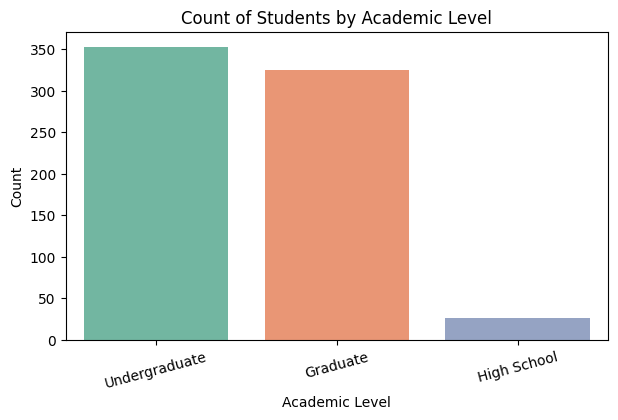

In [24]:
##What is the count of students by academic level? (Bar Chart)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Academic_Level', palette='Set2')
plt.title("Count of Students by Academic Level")
plt.xlabel("Academic Level")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

<ipython-input-25-b9b13e73e47b>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_mental_health.index, y=platform_mental_health.values, palette='coolwarm')


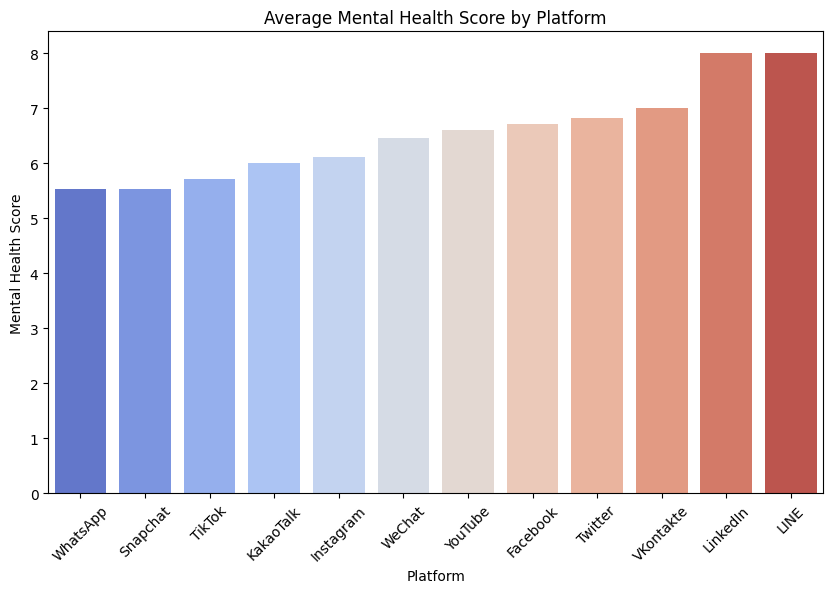

In [25]:
##What is the average mental health score by most used platform? (Bar Plot)
plt.figure(figsize=(10, 6))
platform_mental_health = df.groupby('Most_Used_Platform')['Mental_Health_Score'].mean().sort_values()
sns.barplot(x=platform_mental_health.index, y=platform_mental_health.values, palette='coolwarm')
plt.title("Average Mental Health Score by Platform")
plt.ylabel("Mental Health Score")
plt.xlabel("Platform")
plt.xticks(rotation=45)
plt.show()

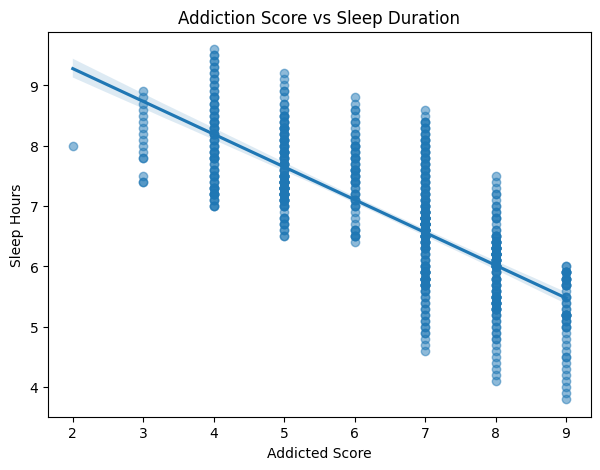

In [26]:
##What is the relationship between sleep hours and addicted score? (Line Plot / Scatter Plot)
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='Addicted_Score', y='Sleep_Hours_Per_Night', scatter_kws={'alpha':0.5})
plt.title("Addiction Score vs Sleep Duration")
plt.xlabel("Addicted Score")
plt.ylabel("Sleep Hours")
plt.show()
